In [1]:
import os
os.chdir("/content")
!rm -rf STAT-7220-Applied-Experimental-Design
print(os.getcwd())

/content


In [2]:

# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "JaredLasley"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW1"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW1


# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to determine if the aging time of ale affects the IBU levels of an IPA.

**Question 2.** Specify the outcome variable

- **Outcome** = IBU(International Bitterness Unit) (continuous numeric variable)

**Question 3.** Specify the independent variable. What are some possible lurking variables?

- **IV** = Weeks (nominal categorical variable).
- **Lurking** = There could be a lurking variable if the different aging tanks have slight variation between them which could affect the final IBUs of each IPA. This could be mitigated by repeating the experiment until all aging length and storage vessel combinations have been evaluated.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

- A completely randomized design would be appropriate here because we have three mutually exclusive treatments we'd like to compare and have no other knowable sources of variation from lurking variables.We are randomly brewing the IPAs without many other sources of variation that we would need to control for in a more complex design.

**Question 5.** State the null and alternative hypotheses for this experiment.

$$ \begin{align}
H_0&: \text{Mean IBUs between 3, 4, and 5 weeks are the same} \\
H_1&: \text{Mean IBUs between 3, 4, or 5 weeks are different}
\end{align}
$$


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

- To interpret these results, we can see that IPAs aged for three weeks about 12 less IBUs than the IPAs aged for four weeks this difference represents about $1.6\sigma$, thus implying a difference of moderate size. Additionally, we can see that there is some overlap of the boxes of 4 and 5 weeks, suggesting there may not be a significant difference between the two groups. In context, these observations support the alternative hypothesis more strongly.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weeks   30 non-null     object 
 1   IBU     30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
           mean       std
Weeks                    
3 Weeks  49.216  8.300656
4 Weeks  62.751  8.250384
5 Weeks  69.725  5.631258


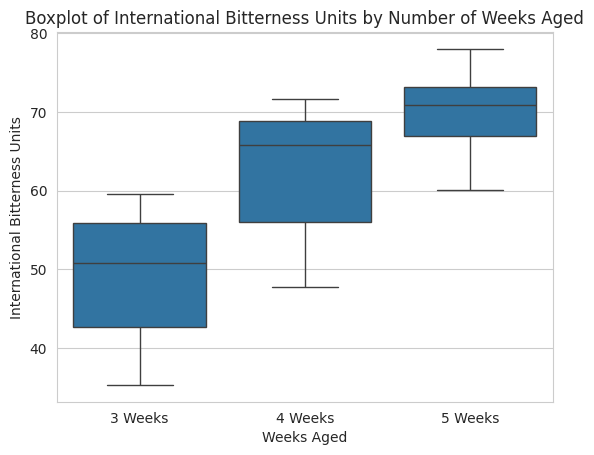

In [6]:
## Import Necessary Packages to Perform Exploratory Analysis ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import Dog Toys.xlsx file ##

ipa = pd.read_excel("IPA.xlsx")

## Check Data Integrity ##

ipa.info()

## Calculate Group Means and Standard Deviations ##

summary_stats = ipa.groupby('Weeks')['IBU'].agg(['mean','std'])

print(summary_stats)

## Generate Boxplots for Visual Comparison ##

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")

## Create boxplot using seaborn ##

sns.boxplot(x="Weeks",y="IBU",data=ipa)

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of International Bitterness Units by Number of Weeks Aged", loc='center')
plt.xlabel("Weeks Aged")
plt.ylabel("International Bitterness Units")
plt.show()

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

- To interpret the results of the normality testing, we can see from the QQ plot that most of the points fall near the line bisecting the graph, with very minimal deviation. While there is some deviation it does not seem substantial and is confined to the end of the tails.Thus, the visual intrepretation suggests normality. This is confirmed by the calculated Shapiro-Wilk P-value of 0.0630. Since $p > \alpha = 0.05$, this tells us the data more strongly supports $$H_0$$, meaning that the assumption of normality is supported by the data.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weeks   30 non-null     object 
 1   IBU     30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
None


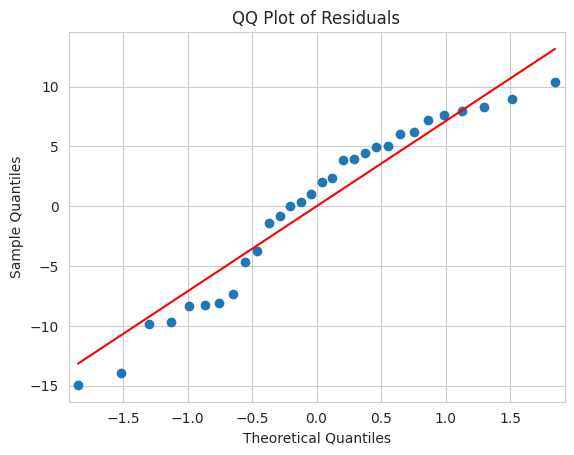

Shapiro-Wilk Test Statistic: 0.9341
Shapiro-Wilk Test P-Value: 0.0630
Fail to reject null hypothesis: Residuals are normally distributed.


In [9]:
## Import Libraries ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

## Import IPA Brewing Data ##

ipa_data = pd.read_excel("IPA.xlsx")

## Data Integrity Check ##

print(ipa.info())

## Fit One Way ANOVA Model ##

ipa_mod = ols("IBU~Weeks",data=ipa_data).fit()

## Extract Model Residuals ##

residuals = ipa_mod.resid

## Generate QQ plot using seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

#Inferential Testing

## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

- As we can see, for each group mean (shown by the vertical lines), the residuals are mostly centered around 0, which implies that the residual mean being approximately 0 seems reasonable. Further, we don't see any points greater than +3 or less than -3, which indicates no obvious outliers. Additionally, each vertical line appears to be of similar height and I do not see any cone shapes appearing in the data. Thus, from visualization I would concluded that the assumption of homoscedasticity is met. This finding is supported by the calculated B-P test p-value of 0.2902. Since $p > \alpha = 0.05$, this tells us the data more strongly supports $$H_0$$, meaning that the assumption of homoscedasticity is supported by the data.

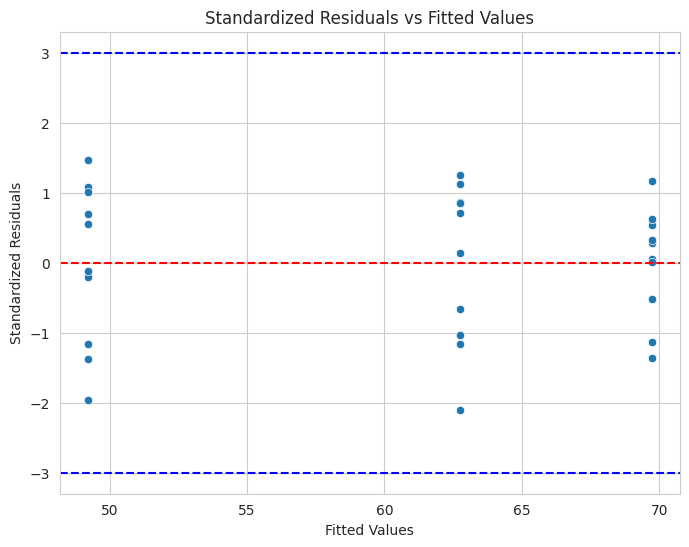

BP Test F-statistic: 1.2952914537529732
BP Test F p-value: 0.2902941540365849
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [10]:
## Obtain Standardized Residuals ##

standardized_residuals = ipa_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = ipa_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

#Inferential Testing of Homoscedasticity

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(ipa_mod.resid,ipa_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")

**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

-The F-statistic and P-value of the one-way ANOVA model are as follows.

F-Statistic: 19.34

P-value: 6.14e-06

Given that p < 0.05 we reject the null hypothesis. the data more strongly supports the alternative hypothesis, indicating that there is a statistically significant difference in mean IBUs between at least two of the aging times.

In [11]:
print(ipa_mod.summary())

                            OLS Regression Results                            
Dep. Variable:                    IBU   R-squared:                       0.589
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     19.34
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           6.14e-06
Time:                        19:59:32   Log-Likelihood:                -101.43
No. Observations:                  30   AIC:                             208.9
Df Residuals:                      27   BIC:                             213.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           49.2160      2.371  

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

- These results, as shown by the adjusted $p < 0.05$, indicate that the mean IBUs for 3 weeks of aging is less than both the 4 and 5 weeks of aging mean IBUs. However, the difference in mean IBUs between 4 weeks of aging and 5 weeks of aging was not found to be statistically different.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
3 Weeks 4 Weeks   13.535 0.0011  5.2205 21.8495   True
3 Weeks 5 Weeks   20.509    0.0 12.1945 28.8235   True
4 Weeks 5 Weeks    6.974 0.1131 -1.3405 15.2885  False
------------------------------------------------------


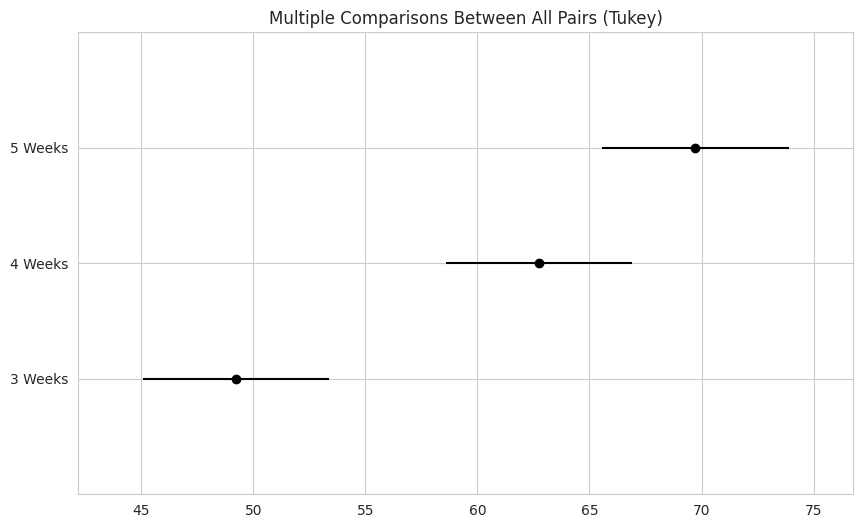

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##

tukey_result = pairwise_tukeyhsd(endog=ipa_data['IBU'], groups=ipa_data['Weeks'],
                                 alpha=0.05)

## Print Tukey Visualization ##

tukey_result.plot_simultaneous()

## Print Tukey Table ##

print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.

- In conclusion our analyses have determined that the length of time an IPA is aged does have an effect on the IBU levels of the IPA. Specifically we determined that there is a statistically significant difference between in IBU levels by aging an IPA for 3 weeks versus 4 or 5 weeks. Potential limiations of the experiment would be unforseen variations in environmental conditions in the aging environment which could have an impact on final IBU levels such as the aging vessels, temperature, humidity, etc. Future experiments of this nature could be improved by improving enviromental controls, increasing the range of aging periods studied to investigate if longer periods than 5 weeks would affect IBU levels, or conducting a greater number of trials for each aging period would increase the robustness of our conclusions.